In [1]:
import sqlite3
db_file = "nextbike_data.db"

try: 
    conn = sqlite3.connect(db_file)
    conn.row_factory = sqlite3.Row
    cur = conn.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [r["name"] for r in cur.fetchall()]
    print(f"Connected to {db_file} - tables: {tables or '(<no tables>)'}")
except sqlite3.Error as e:
    print("SQLite error:", e)
    conn = None
    cur = None

Connected to nextbike_data.db - tables: ['api_data', 'sqlite_sequence', 'bike_locations', 'stations', 'city_summaries', 'scraping_metadata']


In [2]:
import pandas as pd
query = 'SELECT * FROM city_summaries;'

table = pd.read_sql_query(query, conn)
table.head(5)

,id,scrape_id,timestamp,city_uid,city_name,country_name,total_bikes,available_bikes,booked_bikes,set_point_bikes,num_places
0,1,1,2025-09-14 20:38:04.515959,21,Karlsruhe,Germany,857,535,19,857,567
1,2,2,2025-09-14 20:43:04.805354,21,Karlsruhe,Germany,857,537,17,857,568
2,3,3,2025-09-14 20:48:05.107732,21,Karlsruhe,Germany,857,543,20,857,567
3,4,4,2025-09-14 20:53:05.970129,21,Karlsruhe,Germany,857,541,19,857,565
4,5,5,2025-09-14 20:58:06.766290,21,Karlsruhe,Germany,857,534,23,857,566


In [3]:
query_top5 = """
SELECT booked_bikes, available_bikes, total_bikes, timestamp
FROM city_summaries
ORDER BY timestamp DESC
LIMIT 120;
"""

top5 = pd.read_sql_query(query_top5, conn)
top5

,booked_bikes,available_bikes,total_bikes,timestamp
0,27,532,865,2025-11-14 09:36:23.115089
1,25,539,865,2025-11-14 09:31:21.572196
2,25,545,865,2025-11-14 09:26:21.243582
3,26,538,865,2025-11-14 09:21:20.920125
4,30,543,865,2025-11-14 09:16:20.535592
...,...,...,...,...
115,5,551,859,2025-11-14 00:00:34.749921
116,7,551,859,2025-11-13 23:55:34.371356
117,9,550,859,2025-11-13 23:50:34.006149
118,9,547,859,2025-11-13 23:45:33.645612


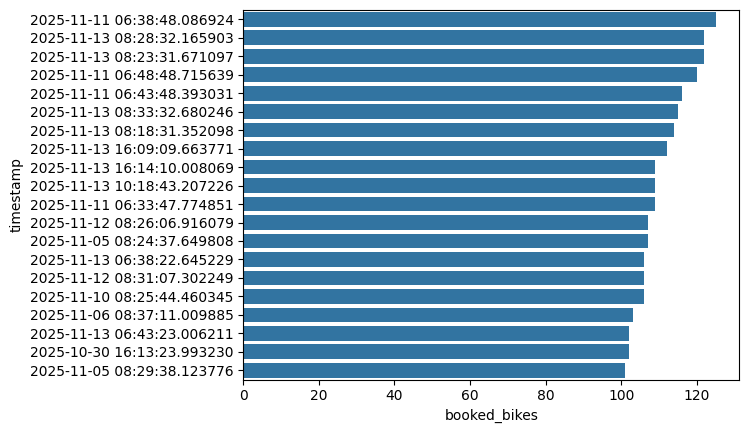

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=top5, x="booked_bikes", y="timestamp")
plt.show()